# Preparing the Sample Files for Merging:

We will include a subset of the sample files and exclude the remaining ones.

## cultures_cohort.parquet file preparing

In [1]:
import pandas as pd

# Load cohort file
sample_folder = "new_sample_one/"
df = pd.read_parquet(sample_folder + "cultures_cohort.parquet")

# Basic sanity checks
print(f"Shape: {df.shape}")
print(f"Number of unique patients: {df['anon_id'].nunique()}")
print(f"Info: {df.info()}")

Shape: (29632, 10)
Number of unique patients: 997
<class 'pandas.DataFrame'>
RangeIndex: 29632 entries, 0 to 29631
Data columns (total 10 columns):
 #   Column                   Non-Null Count  Dtype
---  ------                   --------------  -----
 0   anon_id                  29632 non-null  str  
 1   pat_enc_csn_id_coded     29632 non-null  int64
 2   order_proc_id_coded      29632 non-null  int64
 3   order_time_jittered_utc  29632 non-null  str  
 4   ordering_mode            28870 non-null  str  
 5   culture_description      29632 non-null  str  
 6   was_positive             29632 non-null  Int64
 7   organism                 26722 non-null  str  
 8   antibiotic               26722 non-null  str  
 9   susceptibility           26693 non-null  str  
dtypes: Int64(1), int64(2), str(7)
memory usage: 4.8 MB
Info: None


We begin by loading the primary cohort file (`cultures_cohort.parquet`) to examine its structure and validate the number of observations and unique patients included in the sample.
The dataset contains 29,632 culture records corresponding to 997 unique patients, indicating multiple culture instances per patient.

In [2]:
df['susceptibility'].unique()

<ArrowStringArray>
['Susceptible', 'Intermediate', 'Resistant', nan, 'Synergism', 'Inconclusive']
Length: 6, dtype: str

In [3]:
df['susceptibility'].unique()

<ArrowStringArray>
['Susceptible', 'Intermediate', 'Resistant', nan, 'Synergism', 'Inconclusive']
Length: 6, dtype: str

In [4]:
print(f"# of patients: {df['anon_id'].unique().size}")
print(f"My target susceptibility: {df['susceptibility'].unique()}")

# of patients: 997
My target susceptibility: <ArrowStringArray>
['Susceptible', 'Intermediate', 'Resistant', nan, 'Synergism', 'Inconclusive']
Length: 6, dtype: str


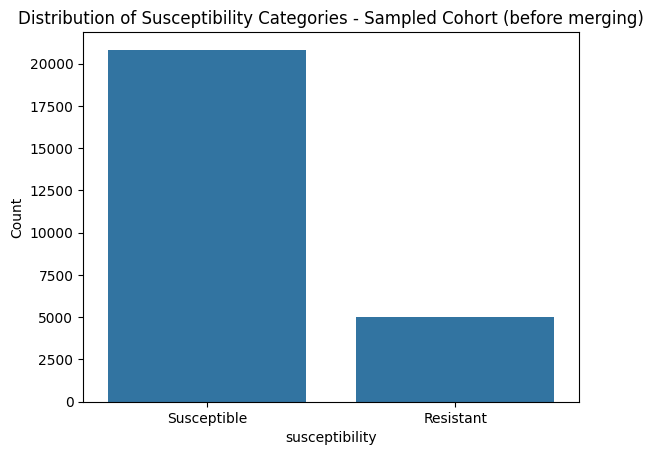

susceptibility
Susceptible     20826
Resistant        5029
Intermediate      801
Synergism          20
Inconclusive       17
Name: count, dtype: int64


In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.countplot(x='susceptibility', data=df, order=['Susceptible', 'Resistant'])
plt.title("Distribution of Susceptibility Categories - Sampled Cohort (before merging)")
plt.ylabel("Count")
plt.show()
print(df['susceptibility'].value_counts())

Although 500 susceptible and 500 resistant patients were selected to ensure patient-level class balance, the resulting row-level distribution remained imbalanced due to multiple culture records per patient. This reflects real-world clinical testing frequency.

In [6]:
df['susceptibility'] = df['susceptibility'].map({
    'Susceptible': 0,
    'Resistant': 1,
})

In [7]:
print(df['susceptibility'].value_counts())


susceptibility
0.0    20826
1.0     5029
Name: count, dtype: int64


In [8]:
df['susceptibility'] = df['susceptibility'].astype('Int8')

In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 29632 entries, 0 to 29631
Data columns (total 10 columns):
 #   Column                   Non-Null Count  Dtype
---  ------                   --------------  -----
 0   anon_id                  29632 non-null  str  
 1   pat_enc_csn_id_coded     29632 non-null  int64
 2   order_proc_id_coded      29632 non-null  int64
 3   order_time_jittered_utc  29632 non-null  str  
 4   ordering_mode            28870 non-null  str  
 5   culture_description      29632 non-null  str  
 6   was_positive             29632 non-null  Int64
 7   organism                 26722 non-null  str  
 8   antibiotic               26722 non-null  str  
 9   susceptibility           25855 non-null  Int8 
dtypes: Int64(1), Int8(1), int64(2), str(6)
memory usage: 4.3 MB


In [10]:
df['was_positive'].value_counts()

was_positive
1    26728
0     2904
Name: count, dtype: Int64

In [11]:
df['ordering_mode'].value_counts()

ordering_mode
Inpatient     16104
Outpatient    12766
Name: count, dtype: int64

In [12]:
df['culture_description'].value_counts()

culture_description
URINE          21908
RESPIRATORY     3870
BLOOD           3854
Name: count, dtype: int64

Drop any cols have zero predictive power.

So the final cleaned file should drop:
- `ordering_mode` (procedural, not useful)
- `culture_description` (likely redundant)
- `was_positive` (constant, uninformative)



In [13]:
df = df.drop(columns=['ordering_mode', 'culture_description', 'was_positive'])


In [14]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 29632 entries, 0 to 29631
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype
---  ------                   --------------  -----
 0   anon_id                  29632 non-null  str  
 1   pat_enc_csn_id_coded     29632 non-null  int64
 2   order_proc_id_coded      29632 non-null  int64
 3   order_time_jittered_utc  29632 non-null  str  
 4   organism                 26722 non-null  str  
 5   antibiotic               26722 non-null  str  
 6   susceptibility           25855 non-null  Int8 
dtypes: Int8(1), int64(2), str(4)
memory usage: 3.2 MB


In [15]:
df['organism'].value_counts()

organism
ESCHERICHIA COLI                        14532
KLEBSIELLA PNEUMONIAE                    2288
STAPHYLOCOCCUS AUREUS                    1579
PROTEUS MIRABILIS                        1461
ENTEROCOCCUS SPECIES                     1015
                                        ...  
NOCARDIA TRANSVALENSIS                      4
BACTEROIDES SPECIES                         4
CORYNEBACTERIUM PSEUDODIPHTHERITICUM        4
NORCARDIA WALLACEI                          4
CORYNEBACTERIUM SPECIES                     4
Name: count, Length: 87, dtype: int64

There are rare organisms (e.g., ≤10 cases) can:
- Add noise
- Cause overfitting
- Make encoding sparse and inefficient

Group Rare Organisms

Group all organisms with fewer than, say, 100 cases into `OTHER`:

In [16]:
organism_counts = df['organism'].value_counts()
common_organisms = organism_counts[organism_counts >= 100].index

df['organism'] = df['organism'].apply(lambda x: x if x in common_organisms else 'OTHER')


In [17]:
df['organism'].value_counts()

organism
ESCHERICHIA COLI                      14532
OTHER                                  4162
KLEBSIELLA PNEUMONIAE                  2288
STAPHYLOCOCCUS AUREUS                  1579
PROTEUS MIRABILIS                      1461
ENTEROCOCCUS SPECIES                   1015
PSEUDOMONAS AERUGINOSA                  929
ENTEROBACTER CLOACAE COMPLEX            495
MUCOID PSEUDOMONAS AERUGINOSA           462
COAG NEGATIVE STAPHYLOCOCCUS            380
ACHROMOBACTER XYLOSOXIDANS              331
STAPH AUREUS {MRSA}                     299
KLEBSIELLA OXYTOCA                      240
STREPTOCOCCUS AGALACTIAE (GROUP B)      221
CITROBACTER KOSERI                      212
CITROBACTER FREUNDII COMPLEX            201
SERRATIA MARCESCENS                     201
PROVIDENCIA RETTGERI                    190
MORGANELLA MORGANII                     170
ENTEROCOCCUS FAECALIS                   163
ZZZENTEROBACTER AEROGENES               101
Name: count, dtype: int64

**Convert Categorical to Numeric for Modeling**

In [18]:
df['organism'] = df['organism'].astype('category')
df['organism'] = df['organism'].cat.codes


In [42]:
df['organism'].value_counts()

organism
7     14532
12     4162
9      2288
18     1579
13     1461
6      1015
15      929
4       495
11      462
3       380
0       331
17      299
8       240
19      221
2       212
1       201
16      201
14      190
10      170
5       163
20      101
Name: count, dtype: int64

In [19]:
df['antibiotic'].value_counts()

antibiotic
Ciprofloxacin                    1858
Gentamicin                       1800
Levofloxacin                     1794
Trimethoprim/Sulfamethoxazole    1772
Ampicillin                       1561
Nitrofurantoin                   1513
Piperacillin/Tazobactam          1447
Cefazolin                        1371
Ceftriaxone                      1182
Meropenem                        1161
Ceftazidime                      1155
Tetracycline                     1150
Amikacin                         1117
Amoxicillin/Clavulanic Acid       949
Tobramycin                        933
Ertapenem                         927
Cefoxitin                         802
Cefepime                          628
Vancomycin                        411
Penicillin                        411
Aztreonam                         376
Ampicillin/Sulbactam              372
Clindamycin                       325
Erythromycin                      322
Linezolid                         269
Oxacillin                         233
M

**Strategy (Same as Organism)**

Group rare antibiotics (less than 100 counts)

In [20]:

antibiotic_counts = df['antibiotic'].value_counts()
common_antibiotics = antibiotic_counts[antibiotic_counts >= 100].index

df['antibiotic'] = df['antibiotic'].apply(lambda x: x if x in common_antibiotics else 'Other')


In [21]:
df['antibiotic'].value_counts()

antibiotic
Other                            3410
Ciprofloxacin                    1858
Gentamicin                       1800
Levofloxacin                     1794
Trimethoprim/Sulfamethoxazole    1772
Ampicillin                       1561
Nitrofurantoin                   1513
Piperacillin/Tazobactam          1447
Cefazolin                        1371
Ceftriaxone                      1182
Meropenem                        1161
Ceftazidime                      1155
Tetracycline                     1150
Amikacin                         1117
Amoxicillin/Clavulanic Acid       949
Tobramycin                        933
Ertapenem                         927
Cefoxitin                         802
Cefepime                          628
Vancomycin                        411
Penicillin                        411
Aztreonam                         376
Ampicillin/Sulbactam              372
Clindamycin                       325
Erythromycin                      322
Linezolid                         269
O

**Convert to Category + Code**

In [22]:
df['antibiotic'] = df['antibiotic'].astype('category')
df['antibiotic'] = df['antibiotic'].cat.codes


In [23]:
df['antibiotic'].value_counts()

antibiotic
21    3410
10    1858
14    1800
16    1794
27    1772
2     1561
20    1513
24    1447
5     1371
9     1182
18    1161
8     1155
25    1150
0     1117
1      949
26     933
12     927
7      802
6      628
28     411
23     411
4      376
3      372
11     325
13     322
17     269
22     233
19     206
15     177
Name: count, dtype: int64

In [ ]:
df.info()

<class 'pandas.DataFrame'>
Index: 25855 entries, 0 to 29626
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype
---  ------                   --------------  -----
 0   anon_id                  25855 non-null  str  
 1   pat_enc_csn_id_coded     25855 non-null  int64
 2   order_proc_id_coded      25855 non-null  int64
 3   order_time_jittered_utc  25855 non-null  str  
 4   organism                 25855 non-null  int8 
 5   antibiotic               25855 non-null  int8 
 6   susceptibility           25855 non-null  Int8 
dtypes: Int8(1), int64(2), int8(2), str(2)
memory usage: 1.9 MB


In [ ]:
df.to_parquet("new_sample_one_processed/processed_cultures_cohort.parquet", index=False)
print(f"The processed_cultures_cohort.parquet is saved :)")

The processed_cultures_cohort.parquet is saved :)


### check cultures_cohort.parquet

In [ ]:
import pandas as pd

df = pd.read_parquet("new_sample_one_processed/processed_cultures_cohort.parquet")
print(f'Shape: {df.shape}')
print(f"# of patients: {df['anon_id'].unique().size}")
print(df['susceptibility'].value_counts())

Shape: (25855, 7)
# of patients: 997
susceptibility
0    20826
1     5029
Name: count, dtype: Int64


In [ ]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 25855 entries, 0 to 25854
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype
---  ------                   --------------  -----
 0   anon_id                  25855 non-null  str  
 1   pat_enc_csn_id_coded     25855 non-null  int64
 2   order_proc_id_coded      25855 non-null  int64
 3   order_time_jittered_utc  25855 non-null  str  
 4   organism                 25855 non-null  int8 
 5   antibiotic               25855 non-null  int8 
 6   susceptibility           25855 non-null  Int8 
dtypes: Int8(1), int64(2), int8(2), str(2)
memory usage: 1.7 MB


## cultures_vitals.parquet file preparing

Processing for `cultures_vitals.parquet`:
The `cultures_vitals.parquet` not have a timestamp column at all:
That means this file (`cultures_vitals.parquet`) already contains aggregated features (e.g., `median`/`first`/`last` only) — not raw time-stamped vitals. So In this case we will:
- Keep cols: `median`, `first`, and `last` values for each vital sign.
- Compute the Delta features: the change between `first` and `last` (e.g., `delta_heartrate`), capturing the trend over time.

The resulting dataset will contain one row per patient with informative, time-aware features that can help predict antibiotic resistance.

In [ ]:
sample_folder = 'new_sample_one/'

vitals = pd.read_parquet(sample_folder + "cultures_vitals.parquet")

print(vitals.columns)
print(vitals.shape)

Index(['anon_id', 'pat_enc_csn_id_coded', 'order_proc_id_coded',
       'Q25_heartrate', 'Q75_heartrate', 'median_heartrate', 'Q25_resprate',
       'Q75_resprate', 'median_resprate', 'Q25_temp', 'Q75_temp',
       'median_temp', 'Q25_sysbp', 'Q75_sysbp', 'median_sysbp', 'Q25_diasbp',
       'Q75_diasbp', 'median_diasbp', 'first_diasbp', 'last_diasbp',
       'last_sysbp', 'first_sysbp', 'last_temp', 'first_temp', 'last_resprate',
       'first_resprate', 'last_heartrate', 'first_heartrate'],
      dtype='str')
(21809, 28)


In [ ]:
vitals.info()

<class 'pandas.DataFrame'>
RangeIndex: 21809 entries, 0 to 21808
Data columns (total 28 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   anon_id               21809 non-null  str    
 1   pat_enc_csn_id_coded  21809 non-null  int64  
 2   order_proc_id_coded   21809 non-null  int64  
 3   Q25_heartrate         21777 non-null  str    
 4   Q75_heartrate         21777 non-null  str    
 5   median_heartrate      21777 non-null  str    
 6   Q25_resprate          21013 non-null  str    
 7   Q75_resprate          21013 non-null  str    
 8   median_resprate       21013 non-null  str    
 9   Q25_temp              21457 non-null  str    
 10  Q75_temp              21457 non-null  str    
 11  median_temp           21457 non-null  str    
 12  Q25_sysbp             21428 non-null  float32
 13  Q75_sysbp             21428 non-null  float32
 14  median_sysbp          21428 non-null  float32
 15  Q25_diasbp            21427 no

In [ ]:
import pandas as pd

vitals_cols = [
    'anon_id', 'pat_enc_csn_id_coded', 'order_proc_id_coded',
    'median_heartrate', 'first_heartrate', 'last_heartrate',
    'median_resprate', 'first_resprate', 'last_resprate',
    'median_temp', 'first_temp', 'last_temp',
    'median_sysbp', 'first_sysbp', 'last_sysbp',
    'median_diasbp', 'first_diasbp', 'last_diasbp'
]

vitals[vitals_cols[3:]] = vitals[vitals_cols[3:]].apply(pd.to_numeric, errors='coerce')

vitals = vitals[vitals_cols]

vital_signs = ['heartrate', 'resprate', 'temp', 'sysbp', 'diasbp']

for v in vital_signs:
    first_col = f'first_{v}'
    last_col = f'last_{v}'
    delta_col = f'delta_{v}'
    vitals[delta_col] = vitals[last_col] - vitals[first_col]


In [ ]:
vitals.info()

<class 'pandas.DataFrame'>
RangeIndex: 21809 entries, 0 to 21808
Data columns (total 23 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   anon_id               21809 non-null  str    
 1   pat_enc_csn_id_coded  21809 non-null  int64  
 2   order_proc_id_coded   21809 non-null  int64  
 3   median_heartrate      21777 non-null  float64
 4   first_heartrate       7224 non-null   float64
 5   last_heartrate        8467 non-null   float64
 6   median_resprate       21013 non-null  float64
 7   first_resprate        5678 non-null   float64
 8   last_resprate         4452 non-null   float64
 9   median_temp           21457 non-null  float64
 10  first_temp            4456 non-null   float64
 11  last_temp             2715 non-null   float64
 12  median_sysbp          21428 non-null  float32
 13  first_sysbp           4451 non-null   float64
 14  last_sysbp            6175 non-null   float64
 15  median_diasbp         21427 no

The vitals data exhibited sparsity in the 7-day pre-culture window, as first and/or last measurements were not consistently available for all encounters. Consequently, delta-based features (computed as last minus first measurements) were missing for a substantial proportion of rows.

To preserve statistical power and avoid introducing selection bias, no encounters were excluded based on delta availability. Instead, both median vital sign features (which had high coverage) and delta features (when available) were retained. Missing delta values were left as-is, and models robust to missing data (e.g., XGBoost) were employed to handle incomplete observations during training.

In [ ]:
float_cols = vitals.select_dtypes(include=['float64']).columns
vitals[float_cols] = vitals[float_cols].astype('float32')

All continuous clinical features were stored using 32-bit floating point precision to reduce memory footprint without affecting numerical stability.

In [ ]:
vitals.info()

<class 'pandas.DataFrame'>
RangeIndex: 21809 entries, 0 to 21808
Data columns (total 23 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   anon_id               21809 non-null  str    
 1   pat_enc_csn_id_coded  21809 non-null  int64  
 2   order_proc_id_coded   21809 non-null  int64  
 3   median_heartrate      21777 non-null  float32
 4   first_heartrate       7224 non-null   float32
 5   last_heartrate        8467 non-null   float32
 6   median_resprate       21013 non-null  float32
 7   first_resprate        5678 non-null   float32
 8   last_resprate         4452 non-null   float32
 9   median_temp           21457 non-null  float32
 10  first_temp            4456 non-null   float32
 11  last_temp             2715 non-null   float32
 12  median_sysbp          21428 non-null  float32
 13  first_sysbp           4451 non-null   float32
 14  last_sysbp            6175 non-null   float32
 15  median_diasbp         21427 no

In [ ]:
vitals.to_parquet("new_sample_one_processed/processed_cultures_vitals.parquet", index=False)
print(f"The processed_cultures_vitals.parquet is saved :)")

The processed_cultures_vitals.parquet is saved :)


## check cultures_vitals.parquet file

In [ ]:

vitals = pd.read_parquet("new_sample_one_processed/processed_cultures_vitals.parquet")
vitals.info()

<class 'pandas.DataFrame'>
RangeIndex: 21809 entries, 0 to 21808
Data columns (total 23 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   anon_id               21809 non-null  str    
 1   pat_enc_csn_id_coded  21809 non-null  int64  
 2   order_proc_id_coded   21809 non-null  int64  
 3   median_heartrate      21777 non-null  float32
 4   first_heartrate       7224 non-null   float32
 5   last_heartrate        8467 non-null   float32
 6   median_resprate       21013 non-null  float32
 7   first_resprate        5678 non-null   float32
 8   last_resprate         4452 non-null   float32
 9   median_temp           21457 non-null  float32
 10  first_temp            4456 non-null   float32
 11  last_temp             2715 non-null   float32
 12  median_sysbp          21428 non-null  float32
 13  first_sysbp           4451 non-null   float32
 14  last_sysbp            6175 non-null   float32
 15  median_diasbp         21427 no

## cultures_labs.parquet file preparing

In [ ]:
import pandas as pd

sample_folder = 'new_sample_one/'
labs = pd.read_parquet(sample_folder + "cultures_labs.parquet")


In [ ]:
print(f"Shape: {labs.shape}")
print("Columns:\n", labs.columns)

Shape: (8655, 59)
Columns:
 Index(['anon_id', 'pat_enc_csn_id_coded', 'order_proc_id_coded', 'Period_Day',
       'Q75_wbc', 'Q25_wbc', 'median_wbc', 'Q25_neutrophils',
       'Q75_neutrophils', 'median_neutrophils', 'Q25_lymphocytes',
       'Q75_lymphocytes', 'median_lymphocytes', 'Q25_hgb', 'Q75_hgb',
       'median_hgb', 'Q25_plt', 'Q75_plt', 'median_plt', 'Q75_na', 'Q25_na',
       'median_na', 'Q75_hco3', 'Q25_hco3', 'median_hco3', 'Q75_bun',
       'Q25_bun', 'median_bun', 'Q75_cr', 'Q25_cr', 'median_cr', 'Q75_lactate',
       'Q25_lactate', 'median_lactate', 'Q75_procalcitonin',
       'Q25_procalcitonin', 'median_procalcitonin', 'first_procalcitonin',
       'last_procalcitonin', 'last_lactate', 'first_lactate', 'last_cr',
       'first_cr', 'last_bun', 'first_bun', 'last_hco3', 'first_hco3',
       'last_na', 'first_na', 'last_plt', 'first_plt', 'last_hgb', 'first_hgb',
       'last_lymphocytes', 'first_lymphocytes', 'last_neutrophils',
       'first_neutrophils', 'last_wbc',

In [ ]:
labs.info()

<class 'pandas.DataFrame'>
RangeIndex: 8655 entries, 0 to 8654
Data columns (total 59 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   anon_id               8655 non-null   str    
 1   pat_enc_csn_id_coded  8655 non-null   int64  
 2   order_proc_id_coded   8655 non-null   int64  
 3   Period_Day            8655 non-null   Int64  
 4   Q75_wbc               8481 non-null   str    
 5   Q25_wbc               8481 non-null   str    
 6   median_wbc            8481 non-null   str    
 7   Q25_neutrophils       2367 non-null   float32
 8   Q75_neutrophils       2367 non-null   float32
 9   median_neutrophils    2367 non-null   float32
 10  Q25_lymphocytes       2385 non-null   float32
 11  Q75_lymphocytes       2385 non-null   float32
 12  median_lymphocytes    2385 non-null   float32
 13  Q25_hgb               8489 non-null   str    
 14  Q75_hgb               8489 non-null   str    
 15  median_hgb            8489 non-n

In [ ]:
import pandas as pd

sample_folder = "new_sample_one/"
labs = pd.read_parquet(sample_folder + "cultures_labs.parquet")

# -----------------------------
# Define columns
# -----------------------------
labs_cols_base = ["anon_id", "pat_enc_csn_id_coded", "order_proc_id_coded"]

labs_vars = [
    "wbc", "neutrophils", "lymphocytes", "hgb", "plt",
    "na", "hco3", "bun", "cr", "lactate", "procalcitonin"
]

median_cols = [f"median_{v}" for v in labs_vars]
first_cols  = [f"first_{v}" for v in labs_vars]
last_cols   = [f"last_{v}" for v in labs_vars]

# Keep only needed columns (ignore if some are missing)
keep_cols = [c for c in (labs_cols_base + median_cols + first_cols + last_cols) if c in labs.columns]
labs = labs[keep_cols].copy()

# -----------------------------
# Step 1 — Convert object/str to numeric
# -----------------------------
num_cols = [c for c in (median_cols + first_cols + last_cols) if c in labs.columns]
labs[num_cols] = labs[num_cols].apply(pd.to_numeric, errors="coerce")

# -----------------------------
# Step 2 — Compute delta only where meaningful (first & last exist)
# -----------------------------
delta_cols = []
for v in labs_vars:
    f = f"first_{v}"
    l = f"last_{v}"
    d = f"delta_{v}"

    if f in labs.columns and l in labs.columns:
        labs[d] = labs[l] - labs[f]
    else:
        labs[d] = pd.NA  # if either column doesn't exist, delta is unavailable

    delta_cols.append(d)

# -----------------------------
# Step 3 — Drop first_* and last_* (keep only median_* and delta_*)
# -----------------------------
drop_cols = [c for c in (first_cols + last_cols) if c in labs.columns]
labs.drop(columns=drop_cols, inplace=True)

# -----------------------------
# Step 4 — Optionally drop extremely sparse labs (by delta coverage)
# -----------------------------
# Keep a delta feature only if it exists in at least this fraction of rows.
min_delta_coverage = 0.01

n = len(labs)
kept_labs = []
kept_delta_cols = []
kept_median_cols = []

for v in labs_vars:
    m = f"median_{v}"
    d = f"delta_{v}"

    # Always require median column to exist to keep that lab in the feature set
    if m not in labs.columns:
        continue

    # If delta column exists, check coverage; otherwise skip delta
    if d in labs.columns:
        coverage = labs[d].notna().sum() / n
        if coverage >= min_delta_coverage:
            kept_delta_cols.append(d)

    kept_labs.append(v)
    kept_median_cols.append(m)

# Rebuild final dataframe using kept medians + kept deltas
labs_final = labs[labs_cols_base + kept_median_cols + kept_delta_cols].copy()

# IMPORTANT: Do NOT drop rows based on missing deltas/medians
# (XGBoost can handle missing values.)

# -----------------------------
# Step 5 — Convert float64 → float32
# -----------------------------
float64_cols = labs_final.select_dtypes(include=["float64"]).columns
labs_final[float64_cols] = labs_final[float64_cols].astype("float32")

print(labs_final.info())

<class 'pandas.DataFrame'>
RangeIndex: 8655 entries, 0 to 8654
Data columns (total 19 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   anon_id               8655 non-null   str    
 1   pat_enc_csn_id_coded  8655 non-null   int64  
 2   order_proc_id_coded   8655 non-null   int64  
 3   median_wbc            8481 non-null   float32
 4   median_neutrophils    2367 non-null   float32
 5   median_lymphocytes    2385 non-null   float32
 6   median_hgb            8489 non-null   float32
 7   median_plt            8475 non-null   float32
 8   median_na             8395 non-null   float32
 9   median_hco3           8438 non-null   float32
 10  median_bun            8418 non-null   float32
 11  median_cr             8485 non-null   float32
 12  median_lactate        3452 non-null   float32
 13  median_procalcitonin  782 non-null    float32
 14  delta_wbc             647 non-null    float32
 15  delta_na              141 non-nu

Laboratory features were engineered within the pre-culture window by retaining central-tendency measurements (`median_*`) for each lab test and deriving change features (`delta_*`) computed as the difference between the last and first available values. All laboratory columns were coerced to numeric values, with non-parsable entries treated as missing. To reduce redundancy and feature dimensionality, `first_*` and `last_*` columns were removed after delta computation, while `median_*` and `delta_*` features were preserved. Extremely sparse delta features were optionally excluded based on a minimum availability threshold to improve model stability without discarding encounters. Finally, continuous features were stored as 32-bit floats to reduce memory footprint, and missing values were retained for downstream models robust to incomplete data.

In [ ]:
labs_final.to_parquet("new_sample_one_processed/processed_cultures_labs.parquet", index=False)
print(f"The processed_cultures_labs.parquet is saved :)")

The processed_cultures_labs.parquet is saved :)


## check processed_cultures_labs.parquet

In [ ]:
import pandas as pd
labs = pd.read_parquet("new_sample_one_processed/processed_cultures_labs.parquet")
labs.info()

<class 'pandas.DataFrame'>
RangeIndex: 8655 entries, 0 to 8654
Data columns (total 19 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   anon_id               8655 non-null   str    
 1   pat_enc_csn_id_coded  8655 non-null   int64  
 2   order_proc_id_coded   8655 non-null   int64  
 3   median_wbc            8481 non-null   float32
 4   median_neutrophils    2367 non-null   float32
 5   median_lymphocytes    2385 non-null   float32
 6   median_hgb            8489 non-null   float32
 7   median_plt            8475 non-null   float32
 8   median_na             8395 non-null   float32
 9   median_hco3           8438 non-null   float32
 10  median_bun            8418 non-null   float32
 11  median_cr             8485 non-null   float32
 12  median_lactate        3452 non-null   float32
 13  median_procalcitonin  782 non-null    float32
 14  delta_wbc             647 non-null    float32
 15  delta_na              141 non-nu

## cultures_meds.parquet file preparing

In [ ]:
import pandas as pd

sample_folder = 'new_sample_one/'
meds = pd.read_parquet(sample_folder + "prior_med.parquet")
meds.info()

<class 'pandas.DataFrame'>
RangeIndex: 110357 entries, 0 to 110356
Data columns (total 7 columns):
 #   Column                          Non-Null Count   Dtype
---  ------                          --------------   -----
 0   anon_id                         110357 non-null  str  
 1   pat_enc_csn_id_coded            110357 non-null  int64
 2   order_proc_id_coded             110357 non-null  int64
 3   order_time_jittered_utc         110357 non-null  str  
 4   medication_name                 110357 non-null  str  
 5   medication_time_to_culturetime  110357 non-null  Int64
 6   medication_category             110357 non-null  str  
dtypes: Int64(1), int64(2), str(4)
memory usage: 11.8 MB


In [ ]:
meds['medication_name'].value_counts()

medication_name
Piperacillin-Tazobactam-Dextrs    19875
Sulfamethoxazole-Trimethoprim     13226
Amoxicillin-Pot Clavulanate        7944
Cefazolin In Dextrose              7140
Cephalexin                         6714
                                  ...  
Flagyl                               31
Fidaxomicin                          20
Tedizolid                            17
Zyvox                                 6
Methenamine Mandelate                 4
Name: count, Length: 86, dtype: int64

In [ ]:
meds['medication_category'].value_counts()

medication_category
PIP     19875
SUL     13226
AMO      7944
CEF1     7140
CEP      6714
        ...  
FLA        31
FID        20
TED        17
ZYV         6
MET3        4
Name: count, Length: 86, dtype: int64

There’s a 1:1 mapping between `medication_name` and `medication_category` - so we  will pick one `medication_category`.

**Convert to Category + Codes**

In [ ]:
meds['medication_category'] = meds['medication_category'].astype('category')
meds['medication_category'] = meds['medication_category'].cat.codes


In [ ]:
meds['medication_category'].value_counts()

medication_category
69    19875
74    13226
1      7944
12     7140
23     6714
      ...  
43       31
42       20
75       17
85        6
61        4
Name: count, Length: 86, dtype: int64

In [ ]:
meds['medication_time_to_culturetime'].value_counts()

medication_time_to_culturetime
0       6873
1        249
22       226
17       226
18       219
        ... 
4056       1
5050       1
3572       1
3940       1
3027       1
Name: count, Length: 4147, dtype: Int64

In [ ]:
meds['medication_time_to_culturetime'].max()

np.int64(5586)

In [ ]:
meds['medication_time_to_culturetime'].min()

np.int64(0)

`medication_time_to_culturetime` has a wide range — from 1 to 5586 days before culture - a range from 0 to 5586 days (~15.3 years):
- Values within a reasonable clinical window, like 0–90 days, are potentially useful.
- These could reflect recent treatments that impact microbiological resistance.
- Very large values (years ago) are likely not relevant to the current infection episode.
- 5586 days is almost certainly old history — e.g., prior admissions, legacy data.
- Including them might introduce noise.

**Bacteria evolve quickly:**
- Resistance can develop or disappear in weeks or months.
- An antibiotic used 5+ years ago probably doesn't affect the bacteria causing an infection today.

We will create binary flag for "any med within 30 days"

In [ ]:
import pandas as pd


meds = meds.drop(columns=['medication_name'])

meds = meds[meds['medication_time_to_culturetime'] <= 180]

meds['med_within_30_days'] = meds['medication_time_to_culturetime'] <= 30


In [ ]:
meds.shape

(27293, 7)

In [ ]:
meds.info()

<class 'pandas.DataFrame'>
Index: 27293 entries, 0 to 110307
Data columns (total 7 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   anon_id                         27293 non-null  str    
 1   pat_enc_csn_id_coded            27293 non-null  int64  
 2   order_proc_id_coded             27293 non-null  int64  
 3   order_time_jittered_utc         27293 non-null  str    
 4   medication_time_to_culturetime  27293 non-null  Int64  
 5   medication_category             27293 non-null  int8   
 6   med_within_30_days              27293 non-null  boolean
dtypes: Int64(1), boolean(1), int64(2), int8(1), str(2)
memory usage: 2.2 MB


In [ ]:
keys = ["anon_id","pat_enc_csn_id_coded","order_proc_id_coded","order_time_jittered_utc"]

print("Max rows per culture:",
      meds.groupby(keys).size().max())

print("Median rows per culture:",
      meds.groupby(keys).size().median())

Max rows per culture: 99
Median rows per culture: 4.0


In [ ]:
keys = ["anon_id","pat_enc_csn_id_coded","order_proc_id_coded","order_time_jittered_utc"]

pm_agg = (
    meds.groupby(keys)
      .agg({
          "med_within_30_days": "max",               
          "medication_category": "nunique",         
          "medication_time_to_culturetime": "min"   
      })
      .reset_index()
)

pm_agg = pm_agg.rename(columns={
    "medication_category": "n_med_categories",
    "medication_time_to_culturetime": "min_time_to_med"
})

Medication records were aggregated at the culture-event level to ensure one observation per microbiological encounter. Because multiple medication administrations may precede a single culture, antibiotic exposures were grouped by patient and culture identifiers, and summary features were derived. Specifically, we computed: (1) a binary indicator of any antibiotic exposure within 30 days prior to culture collection (`med_within_30_days`), capturing recent selective pressure; (2) the number of distinct antibiotic categories administered before the culture (`n_med_categories`), reflecting treatment diversity and exposure intensity; and (3) the minimum time in days between antibiotic administration and culture collection (`min_time_to_med`), representing recency of exposure. This aggregation reduced row-level duplication, preserved clinically meaningful signals, and improved model interpretability while preventing dimensional expansion from multiple medication records per encounter.

In [ ]:
pm_agg.info()

<class 'pandas.DataFrame'>
RangeIndex: 3513 entries, 0 to 3512
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   anon_id                  3513 non-null   str    
 1   pat_enc_csn_id_coded     3513 non-null   int64  
 2   order_proc_id_coded      3513 non-null   int64  
 3   order_time_jittered_utc  3513 non-null   str    
 4   med_within_30_days       3513 non-null   boolean
 5   n_med_categories         3513 non-null   int64  
 6   min_time_to_med          3513 non-null   Int64  
dtypes: Int64(1), boolean(1), int64(3), str(2)
memory usage: 284.5 KB


In [ ]:
pm_agg["n_med_categories"] = pm_agg["n_med_categories"].astype("int32")
pm_agg["min_time_to_med"] = pd.to_numeric(pm_agg["min_time_to_med"], errors="coerce").astype("Int32")


In [ ]:
pm_agg.info()

<class 'pandas.DataFrame'>
RangeIndex: 3513 entries, 0 to 3512
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   anon_id                  3513 non-null   str    
 1   pat_enc_csn_id_coded     3513 non-null   int64  
 2   order_proc_id_coded      3513 non-null   int64  
 3   order_time_jittered_utc  3513 non-null   str    
 4   med_within_30_days       3513 non-null   boolean
 5   n_med_categories         3513 non-null   int32  
 6   min_time_to_med          3513 non-null   Int32  
dtypes: Int32(1), boolean(1), int32(1), int64(2), str(2)
memory usage: 257.0 KB


In [ ]:
pm_agg.to_parquet("new_sample_one_processed/processed_prior_med.parquet", index=False)
print(f"The processed_prior_med.parquet is saved :)")

The processed_prior_med.parquet is saved :)


## check /processed_prior_med.parquet file

In [ ]:
import pandas as pd

meds = pd.read_parquet("new_sample_one_processed/processed_prior_med.parquet")
meds.info()


<class 'pandas.DataFrame'>
RangeIndex: 3513 entries, 0 to 3512
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   anon_id                  3513 non-null   str    
 1   pat_enc_csn_id_coded     3513 non-null   int64  
 2   order_proc_id_coded      3513 non-null   int64  
 3   order_time_jittered_utc  3513 non-null   str    
 4   med_within_30_days       3513 non-null   boolean
 5   n_med_categories         3513 non-null   int32  
 6   min_time_to_med          3513 non-null   Int32  
dtypes: Int32(1), boolean(1), int32(1), int64(2), str(2)
memory usage: 256.2 KB


## cultures_demographics.parquet file praparing

In [ ]:
import pandas as pd

demo = pd.read_parquet("new_sample_one/cultures_demographics.parquet")
demo.info()

<class 'pandas.DataFrame'>
RangeIndex: 4875 entries, 0 to 4874
Data columns (total 5 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   anon_id               4875 non-null   str  
 1   pat_enc_csn_id_coded  4875 non-null   int64
 2   order_proc_id_coded   4875 non-null   int64
 3   age                   4875 non-null   str  
 4   gender                4875 non-null   str  
dtypes: int64(2), str(3)
memory usage: 287.9 KB


In [ ]:
demo['gender'].value_counts()

gender
0    3285
1    1590
Name: count, dtype: int64

In [ ]:
# Map gender to binary
gender_map = {
    "0": 0, # female
    "1": 1 # male
}

demo["gender"] = demo["gender"].map(gender_map).astype("Int8")

In [ ]:
demo.info()

<class 'pandas.DataFrame'>
RangeIndex: 4875 entries, 0 to 4874
Data columns (total 5 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   anon_id               4875 non-null   str  
 1   pat_enc_csn_id_coded  4875 non-null   int64
 2   order_proc_id_coded   4875 non-null   int64
 3   age                   4875 non-null   str  
 4   gender                4875 non-null   Int8 
dtypes: Int8(1), int64(2), str(2)
memory usage: 254.6 KB


In [ ]:
demo['age'].value_counts()

age
65-74 years    928
75-84 years    855
55-64 years    681
25-34 years    662
45-54 years    521
35-44 years    411
18-24 years    282
85-89 years    279
above 90       256
Name: count, dtype: int64

`gender` is encoded as `0` and `1`.

`age` is in age group strings (e.g., `'18-24 years`) — we’ll convert this into ordinal or numeric features. 
And downcast integer columns


In [ ]:
age_order = {
    "18-24 years": 0,
    "25-34 years": 1,
    "35-44 years": 2,
    "45-54 years": 3,
    "55-64 years": 4,
    "65-74 years": 5,
    "75-84 years": 6,
    "85-89 years": 7,
    "above 90":    8,
}

demo["age"] = demo["age"].map(age_order).astype("Int8")

In [ ]:
demo['age'].value_counts()

age
5    928
6    855
4    681
1    662
3    521
2    411
0    282
7    279
8    256
Name: count, dtype: Int64

In [ ]:
demo.info()

<class 'pandas.DataFrame'>
RangeIndex: 4875 entries, 0 to 4874
Data columns (total 5 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   anon_id               4875 non-null   str  
 1   pat_enc_csn_id_coded  4875 non-null   int64
 2   order_proc_id_coded   4875 non-null   int64
 3   age                   4875 non-null   Int8 
 4   gender                4875 non-null   Int8 
dtypes: Int8(2), int64(2), str(1)
memory usage: 174.4 KB


In [ ]:
demo.to_parquet("new_sample_one_processed/processed_cultures_demographics.parquet", index=False)
print(f"The processed_cultures_demographics.parquet is saved :)")

The processed_cultures_demographics.parquet is saved :)


## check processed_cultures_demographics.parquet file

In [ ]:
import pandas as pd
demo = pd.read_parquet("new_sample_one_processed/processed_cultures_demographics.parquet")
demo.info()

<class 'pandas.DataFrame'>
RangeIndex: 4875 entries, 0 to 4874
Data columns (total 5 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   anon_id               4875 non-null   str  
 1   pat_enc_csn_id_coded  4875 non-null   int64
 2   order_proc_id_coded   4875 non-null   int64
 3   age                   4875 non-null   Int8 
 4   gender                4875 non-null   Int8 
dtypes: Int8(2), int64(2), str(1)
memory usage: 174.4 KB


## antibiotic_class_exposure.parquet file preparing 

In [ ]:
import pandas as pd
class_df = pd.read_parquet("new_sample_one/antibiotic_class_exposure.parquet")
class_df.info()


<class 'pandas.DataFrame'>
RangeIndex: 63174 entries, 0 to 63173
Data columns (total 8 columns):
 #   Column                   Non-Null Count  Dtype
---  ------                   --------------  -----
 0   anon_id                  63174 non-null  str  
 1   pat_enc_csn_id_coded     63174 non-null  int64
 2   order_proc_id_coded      63174 non-null  int64
 3   order_time_jittered_utc  63174 non-null  str  
 4   medication_category      63174 non-null  str  
 5   medication_name          63174 non-null  str  
 6   antibiotic_class         63174 non-null  str  
 7   time_to_culturetime      63174 non-null  Int64
dtypes: Int64(1), int64(2), str(5)
memory usage: 8.0 MB


To construct antibiotic exposure features, the `antibiotic_class_exposure` dataset was streamlined to retain only clinically relevant variables. Redundant columns (`medication_name` and `medication_category`) were removed, as detailed medication information was preserved separately in the primary medication dataset. The analysis focused on antibiotic class–level exposure, retaining `antibiotic_class` and the corresponding `time_to_culturetime` variable.

Because multiple administrations of the same antibiotic class may occur prior to a single culture event, records were aggregated at the culture–class level. Specifically, for each unique culture event (defined by patient and encounter identifiers), the minimum time to culture (`min(time_to_culturetime)`) was computed per antibiotic class, representing the most recent exposure before culture collection. This approach reduced row-level duplication while preserving clinically meaningful information regarding recency of antibiotic exposure, which is biologically relevant to antimicrobial resistance development.

In [ ]:
import pandas as pd

keys = ["anon_id","pat_enc_csn_id_coded","order_proc_id_coded","order_time_jittered_utc"]

# 1) Keep only needed columns
class_df = class_df[keys + ["antibiotic_class", "time_to_culturetime"]].copy()

# 2) Ensure numeric time
class_df["time_to_culturetime"] = pd.to_numeric(class_df["time_to_culturetime"], errors="coerce").astype("Int32")

# 3) Aggregate: keep most recent exposure per class per culture (min time)
cls_agg = (
    class_df.groupby(keys + ["antibiotic_class"], as_index=False)
       .agg(min_time_to_class=("time_to_culturetime", "min"))
)
cls_agg["antibiotic_class"] = (
    cls_agg["antibiotic_class"]
    .astype("category")
    .cat.codes
    .astype("Int8")
)
print(cls_agg.shape)
print(cls_agg.info())

(13759, 6)
<class 'pandas.DataFrame'>
RangeIndex: 13759 entries, 0 to 13758
Data columns (total 6 columns):
 #   Column                   Non-Null Count  Dtype
---  ------                   --------------  -----
 0   anon_id                  13759 non-null  str  
 1   pat_enc_csn_id_coded     13759 non-null  int64
 2   order_proc_id_coded      13759 non-null  int64
 3   order_time_jittered_utc  13759 non-null  str  
 4   antibiotic_class         13759 non-null  Int8 
 5   min_time_to_class        13759 non-null  Int32
dtypes: Int32(1), Int8(1), int64(2), str(2)
memory usage: 979.3 KB
None


In [ ]:
cls_agg.to_parquet("new_sample_one_processed/processed_antibiotic_class_exposure.parquet", index=False)
print(f"The processed_antibiotic_class_exposure.parquet is saved :)")

The processed_antibiotic_class_exposure.parquet is saved :)


## check antibiotic_class_exposure.parquet 

In [ ]:
import pandas as dp

class_df = pd.read_parquet("new_sample_one_processed/processed_antibiotic_class_exposure.parquet")
class_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 13759 entries, 0 to 13758
Data columns (total 6 columns):
 #   Column                   Non-Null Count  Dtype
---  ------                   --------------  -----
 0   anon_id                  13759 non-null  str  
 1   pat_enc_csn_id_coded     13759 non-null  int64
 2   order_proc_id_coded      13759 non-null  int64
 3   order_time_jittered_utc  13759 non-null  str  
 4   antibiotic_class         13759 non-null  Int8 
 5   min_time_to_class        13759 non-null  Int32
dtypes: Int32(1), Int8(1), int64(2), str(2)
memory usage: 975.9 KB


## cultures_comorbidity.parquet file preparing

In [ ]:
import pandas as pd
como = pd.read_parquet("new_sample_one/cultures_comorbidity.parquet")
como.info()


<class 'pandas.DataFrame'>
RangeIndex: 2277646 entries, 0 to 2277645
Data columns (total 7 columns):
 #   Column                                    Dtype  
---  ------                                    -----  
 0   anon_id                                   str    
 1   pat_enc_csn_id_coded                      int64  
 2   order_proc_id_coded                       int64  
 3   order_time_jittered_utc                   str    
 4   comorbidity_component                     str    
 5   comorbidity_component_start_days_culture  Int64  
 6   comorbidity_component_end_days_culture    float32
dtypes: Int64(1), float32(1), int64(2), str(3)
memory usage: 253.7 MB


In [ ]:
print(f'Max comorbidity_component_start_days_culture = {como["comorbidity_component_start_days_culture"].max()}')
print(f'Min comorbidity_component_start_days_culture = {como["comorbidity_component_start_days_culture"].min()}')
print(f'Max comorbidity_component_end_days_culture = {como["comorbidity_component_end_days_culture"].max()}')
print(f'Min comorbidity_component_end_days_culture = {como["comorbidity_component_end_days_culture"].min()}')

Max comorbidity_component_start_days_culture = 7891
Min comorbidity_component_start_days_culture = 0
Max comorbidity_component_end_days_culture = 5565.0
Min comorbidity_component_end_days_culture = -5013.0


In [ ]:
como.shape

(2277646, 7)

In [ ]:
como['comorbidity_component'].value_counts().head(20)

comorbidity_component
Congestive heart failure                                          230026
Other specified status                                             60619
Abnormal findings without diagnosis                                57061
Organ transplant status                                            52370
Personal/family history of disease                                 49741
Renal failure                                                      49522
Abdominal pain and other digestive/abdomen signs and symptoms      42517
Chronic kidney disease                                             40368
Disorders of lipid metabolism                                      33470
Urinary tract infections                                           33064
Aplastic anemia                                                    32687
Other specified and unspecified diseases of kidney and ureters     31576
Cystic fibrosis                                                    30418
Cardiac dysrhythmias         

In [ ]:
len(como['comorbidity_component'].value_counts())

466

In [ ]:
import re

def map_comorbidity_to_group(label: str) -> str:
    s = label.lower()

    # diabetes
    if "diabetes" in s:
        return "has_diabetes"

    # heart failure / CHF
    if ("congestive heart failure" in s) or ("heart failure" in s) or ("chf" in s):
        return "has_chf"

    # kidney disease
    if ("chronic kidney" in s) or ("ckd" in s) or ("renal failure" in s) or ("nephritis" in s) or ("nephrosis" in s) or ("renal sclerosis" in s):
        return "has_ckd"

    # cancer / malignancy
    if any(k in s for k in ["cancer", "malignant", "neoplasm", "leukemia", "lymphoma", "myeloma", "metastatic", "sarcoma", "tumor"]):
        return "has_cancer"

    # transplant
    if "transplant" in s:
        return "has_transplant"

    # immunosuppression / immunity disorders / HIV
    if any(k in s for k in ["immunity disorder", "immunodeficiency", "hiv", "aids", "immunosuppress"]):
        return "has_immunosuppression"

    # COPD / chronic pulmonary
    if any(k in s for k in ["copd", "emphysema", "chronic bronchitis", "bronchiectasis", "chronic pulmonary disease"]):
        return "has_copd"

    # liver disease
    if any(k in s for k in ["cirrhosis", "hepatic", "hepatitis", "liver disease", "liver failure"]):
        return "has_liver_disease"

    # dementia
    if any(k in s for k in ["dementia", "alzheimer", "neurocognitive"]):
        return "has_dementia"

    # stroke / CVA / cerebrovascular
    if any(k in s for k in ["stroke", "cva", "cerebral infarction", "cerebrovascular", "transient cerebral ischemia"]):
        return "has_stroke"

    return "has_other_comorbid"

In [ ]:
keys = ["anon_id","pat_enc_csn_id_coded","order_proc_id_coded","order_time_jittered_utc"]

active = como[
    (como["comorbidity_component_start_days_culture"] >= 0) &
    ((como["comorbidity_component_end_days_culture"].isna()) | (como["comorbidity_component_end_days_culture"] >= 0))
].copy()

active["group"] = active["comorbidity_component"].apply(map_comorbidity_to_group)

grouped_wide = (
    pd.crosstab(index=[active[k] for k in keys], columns=active["group"])
      .clip(upper=1).astype("int8").reset_index()
)

# ensure all expected columns exist
expected = [
    "has_diabetes","has_chf","has_ckd","has_cancer","has_transplant",
    "has_immunosuppression","has_copd","has_liver_disease","has_dementia",
    "has_stroke","has_other_comorbid"
]
for c in expected:
    if c not in grouped_wide.columns:
        grouped_wide[c] = 0

grouped_wide = grouped_wide[keys + expected]
print(grouped_wide.shape)

(4739, 15)


In [ ]:
grouped_wide.info()

<class 'pandas.DataFrame'>
RangeIndex: 4739 entries, 0 to 4738
Data columns (total 15 columns):
 #   Column                   Non-Null Count  Dtype
---  ------                   --------------  -----
 0   anon_id                  4739 non-null   str  
 1   pat_enc_csn_id_coded     4739 non-null   int64
 2   order_proc_id_coded      4739 non-null   int64
 3   order_time_jittered_utc  4739 non-null   str  
 4   has_diabetes             4739 non-null   int8 
 5   has_chf                  4739 non-null   int8 
 6   has_ckd                  4739 non-null   int8 
 7   has_cancer               4739 non-null   int8 
 8   has_transplant           4739 non-null   int8 
 9   has_immunosuppression    4739 non-null   int8 
 10  has_copd                 4739 non-null   int8 
 11  has_liver_disease        4739 non-null   int8 
 12  has_dementia             4739 non-null   int8 
 13  has_stroke               4739 non-null   int8 
 14  has_other_comorbid       4739 non-null   int8 
dtypes: int64(2), in

In [ ]:
grouped_wide.to_parquet("new_sample_one_processed/processed_cultures_comorbidity.parquet", index=False)
print("The processed_cultures_comorbidity.parquet is saved :)")

The processed_cultures_comorbidity.parquet is saved :)


## check cultures_comorbidity.parquet file

In [ ]:
import pandas as pd
como = pd.read_parquet("new_sample_one_processed/processed_cultures_comorbidity.parquet")
como.info()

<class 'pandas.DataFrame'>
RangeIndex: 4739 entries, 0 to 4738
Data columns (total 15 columns):
 #   Column                   Non-Null Count  Dtype
---  ------                   --------------  -----
 0   anon_id                  4739 non-null   str  
 1   pat_enc_csn_id_coded     4739 non-null   int64
 2   order_proc_id_coded      4739 non-null   int64
 3   order_time_jittered_utc  4739 non-null   str  
 4   has_diabetes             4739 non-null   int8 
 5   has_chf                  4739 non-null   int8 
 6   has_ckd                  4739 non-null   int8 
 7   has_cancer               4739 non-null   int8 
 8   has_transplant           4739 non-null   int8 
 9   has_immunosuppression    4739 non-null   int8 
 10  has_copd                 4739 non-null   int8 
 11  has_liver_disease        4739 non-null   int8 
 12  has_dementia             4739 non-null   int8 
 13  has_stroke               4739 non-null   int8 
 14  has_other_comorbid       4739 non-null   int8 
dtypes: int64(2), in